In [90]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd. read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

import xgboost as xgb
import lightgbm as lgb

In [91]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [92]:

print("PURCHASE INTENT PREDICTION - DUAL OUTPUT PIPELINE")
print("=" * 60)
print("This pipeline creates two submission files:")
print("1. submission_probability.csv - Probability predictions (0-1)")
print("2. submission_binary.csv - Binary predictions (0 or 1)")
print("=" * 60)

PURCHASE INTENT PREDICTION - DUAL OUTPUT PIPELINE
This pipeline creates two submission files:
1. submission_probability.csv - Probability predictions (0-1)
2. submission_binary.csv - Binary predictions (0 or 1)


In [93]:
# Load data
print("\nStep 1: Loading datasets...")
train_df = pd.read_excel('kaggle/Training_Dataset.xlsx')
test_df = pd.read_excel('kaggle/Testing_Dateset.xlsx')
sample_submission = pd.read_excel('kaggle/sample_Submission.xlsx')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"Sample submission shape: {sample_submission.shape}")


Step 1: Loading datasets...
Training data shape: (177086, 23)
Test data shape: (44272, 23)
Sample submission shape: (4, 2)
Training data shape: (177086, 23)
Test data shape: (44272, 23)
Sample submission shape: (4, 2)


### Visualizations Before Data Processing

/var/folders/0j/n9gvt8712g905vzp6jvsf4nc0000gp/T/ipykernel_14460/4139458623.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1, 0], palette='viridis')
/var/folders/0j/n9gvt8712g905vzp6jvsf4nc0000gp/T/ipykernel_14460/4139458623.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=years, order=years.value_counts().index, ax=axes[1, 1], palette='Blues_r')


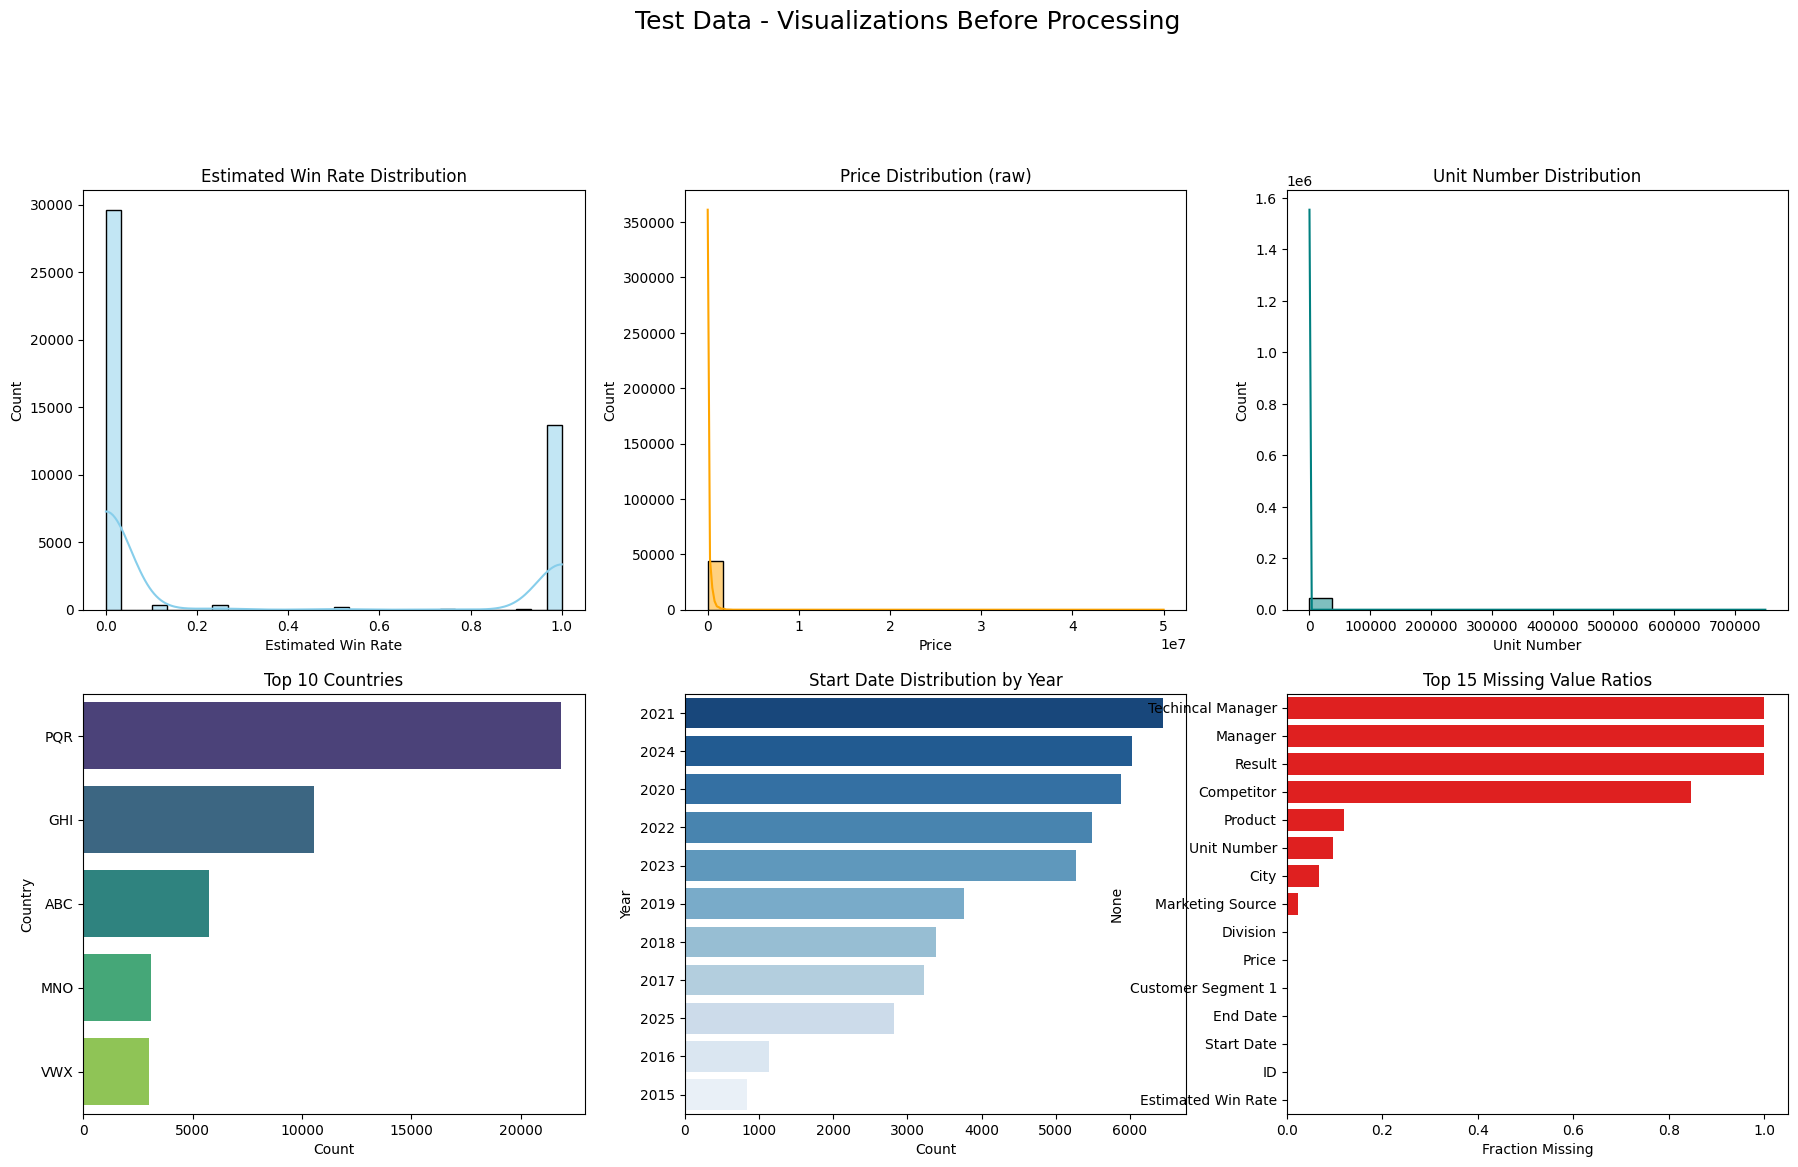

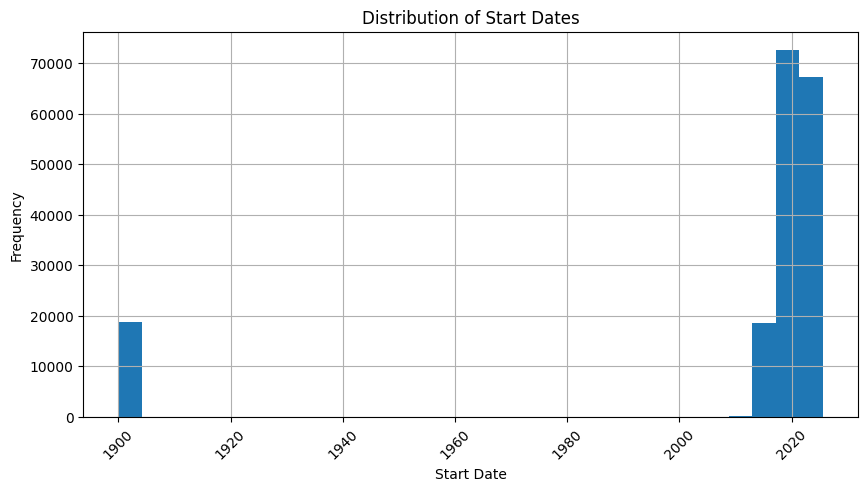

<Figure size 640x480 with 0 Axes>

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up a grid for multiple plots
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle("Test Data - Visualizations Before Processing", fontsize=18, y=1.03)

# 1. Distribution of Estimated Win Rate (raw)
sns.histplot(test_df['Estimated Win Rate'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Estimated Win Rate Distribution')
axes[0, 0].set_xlabel('Estimated Win Rate')

# 2. Distribution of Price (raw)
sns.histplot(test_df['Price'], bins=30, kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Price Distribution (raw)')
axes[0, 1].set_xlabel('Price')

# 3. Distribution of Unit Number (raw, fillna with 0 for display)
sns.histplot(test_df['Unit Number'].fillna(0), bins=20, kde=True, ax=axes[0, 2], color='teal')
axes[0, 2].set_title('Unit Number Distribution')
axes[0, 2].set_xlabel('Unit Number')

# 4. Top 10 Countries
top_countries = test_df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Top 10 Countries')
axes[1, 0].set_xlabel('Count')

# 5. Start Date Distribution (by year)
years = test_df['Start Date'].dt.year
sns.countplot(y=years, order=years.value_counts().index, ax=axes[1, 1], palette='Blues_r')
axes[1, 1].set_title('Start Date Distribution by Year')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('Year')

#
missing = test_df.isnull().mean().sort_values(ascending=False).head(15)
sns.barplot(x=missing.values, y=missing.index, ax=axes[1, 2], color='red')
axes[1, 2].set_title('Top 15 Missing Value Ratios')
axes[1, 2].set_xlabel('Fraction Missing')

# Make sure Start Date is datetime
train_df['Start Date'] = pd.to_datetime(train_df['Start Date'], errors='coerce')

plt.figure(figsize=(10,5))
train_df['Start Date'].hist(bins=30)  # adjust bins for more/less granularity
plt.title("Distribution of Start Dates")
plt.xlabel("Start Date")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### PreProcessing the Data

In [94]:
print("\nStep 2: Preprocessing data...")
print(train_df.head())




Step 2: Preprocessing data...
   ID Start Date   End Date  Estimated Win Rate     Price Customer Segment 1  \
0   1 2021-03-16 2021-04-20                0.75   3270.83                  I   
1   2 2021-03-18 2021-08-16                0.50   3772.74                  I   
2   3 2021-04-01 2021-09-03                0.10   2230.27                  I   
3   4 2021-04-08 2021-07-01                0.50   5000.00                  I   
4   5 2021-03-17 2023-08-24                0.20  51506.23                  I   

  Customer Segment 2 Customer Segment 3 Customer Segment 4 Customer Segment 5  \
0                  A                 AA                CCC                 AB   
1                  A                 AA                CCC                 AB   
2                  A                 AA                CCC                 AB   
3                  A                 AA                CCC                 AB   
4                  A                 AA                CCC                 AB   

 

In [95]:
print(train_df.columns.values)
print("=" * 60)
print(test_df.columns.values)

['ID' 'Start Date' 'End Date' 'Estimated Win Rate' 'Price'
 'Customer Segment 1' 'Customer Segment 2' 'Customer Segment 3'
 'Customer Segment 4' 'Customer Segment 5' 'Unit Number' 'Activity 1'
 'Activity 2' 'Country' 'City' 'Product' 'Competitor' 'Marketing Source'
 'Division' 'Manager' 'Techincal Manager' 'Customer ID' 'Result']
['ID' 'Start Date' 'End Date' 'Estimated Win Rate' 'Price'
 'Customer Segment 1' 'Customer Segment 2' 'Customer Segment 3'
 'Customer Segment 4' 'Customer Segment 5' 'Unit Number' 'Activity 1'
 'Activity 2' 'Country' 'City' 'Product' 'Competitor' 'Marketing Source'
 'Division' 'Manager' 'Techincal Manager' 'Customer ID' 'Result']


In [96]:
train_df.info() 
test_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177086 entries, 0 to 177085
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ID                  177086 non-null  int64         
 1   Start Date          177086 non-null  datetime64[ns]
 2   End Date            177086 non-null  datetime64[ns]
 3   Estimated Win Rate  166527 non-null  float64       
 4   Price               177086 non-null  float64       
 5   Customer Segment 1  177086 non-null  object        
 6   Customer Segment 2  177086 non-null  object        
 7   Customer Segment 3  177086 non-null  object        
 8   Customer Segment 4  177086 non-null  object        
 9   Customer Segment 5  177086 non-null  object        
 10  Unit Number         177086 non-null  int64         
 11  Activity 1          177086 non-null  object        
 12  Activity 2          177086 non-null  object        
 13  Country             177086 no

In [97]:
train_df.describe()

,ID,Start Date,End Date,Estimated Win Rate,Price,Unit Number,Result
count,177086.000000,177086,177086,166527.000000,1.770860e+05,1.770860e+05,177086.000000
mean,88543.500000,2007-11-01 05:39:18.054278656,2020-01-11 03:58:30.551934720,0.644918,1.050347e+05,6.918477e+03,0.427278
min,1.000000,1900-01-01 00:00:00,1900-01-01 00:00:00,0.000000,-9.067000e+02,0.000000e+00,0.000000
25%,44272.250000,2017-09-07 00:00:00,2018-03-30 00:00:00,0.300000,4.162925e+03,0.000000e+00,0.000000
50%,88543.500000,2020-02-17 00:00:00,2020-11-25 00:00:00,0.750000,1.500000e+04,1.000000e+00,0.000000
75%,132814.750000,2022-07-28 00:00:00,2023-03-15 00:00:00,1.000000,7.058903e+04,1.000000e+00,1.000000
max,177086.000000,2025-08-04 00:00:00,2030-01-01 00:00:00,1.000000,2.470946e+07,1.200000e+09,1.000000
std,51120.469222,NaN,NaN,0.352903,2.874420e+05,2.851892e+06,0.494685


In [98]:
train_df.describe(include=['O'])

,Customer Segment 1,Customer Segment 2,Customer Segment 3,Customer Segment 4,Customer Segment 5,Activity 1,Activity 2,Country,City,Product,Competitor,Marketing Source,Division,Manager,Techincal Manager,Customer ID
count,177086,177086,177086,177086,177086,177086,177086,177086,177030,177044,175980,177035,177085,153061,10354,177086
unique,7,5,7,4,2,2,2,8,25,163,186,45,44,1202,325,52865
top,I,A,AA,CCC,AB,EF,IJ,ABC,SME278,JNQ525,AAB162,PWH228,SX68,8006315,8006138,641421
freq,68889,107791,68889,174956,166541,167267,141523,61224,44626,22833,148503,133139,41512,4773,653,1096


# STEP 1: DATA CLEAN UP & FILLING MISSING VALUES

In [100]:
# Preprocessing: handle missing values and basic cleaning

# For train_df
train_df_clean = train_df.copy()
# Fill missing Estimated Win Rate with median
train_df_clean['Estimated Win Rate'] = train_df_clean['Estimated Win Rate'].fillna(train_df_clean['Estimated Win Rate'].median())
# Fill missing Price with median
train_df_clean['Price'] = train_df_clean['Price'].fillna(train_df_clean['Price'].median())
# Fill missing Unit Number with 0
train_df_clean['Unit Number'] = train_df_clean['Unit Number'].fillna(0)
# Fill missing categorical columns with 'missing'
for col in train_df_clean.select_dtypes(include=['object']).columns:
    train_df_clean[col] = train_df_clean[col].fillna('missing')

# For test_df
test_df_clean = test_df.copy()
test_df_clean['Estimated Win Rate'] = test_df_clean['Estimated Win Rate'].fillna(test_df_clean['Estimated Win Rate'].median())
test_df_clean['Price'] = test_df_clean['Price'].fillna(test_df_clean['Price'].median())
test_df_clean['Unit Number'] = test_df_clean['Unit Number'].fillna(0)
for col in test_df_clean.select_dtypes(include=['object']).columns:
    test_df_clean[col] = test_df_clean[col].fillna('missing')

print("Preprocessing completed. Missing values handled.")

Preprocessing completed. Missing values handled.


### CHECKING IF WE STILL HAVE NULL VALUES IN OUR DATA

In [101]:
print(train_df_clean.info())
print(test_df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177086 entries, 0 to 177085
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ID                  177086 non-null  int64         
 1   Start Date          177086 non-null  datetime64[ns]
 2   End Date            177086 non-null  datetime64[ns]
 3   Estimated Win Rate  177086 non-null  float64       
 4   Price               177086 non-null  float64       
 5   Customer Segment 1  177086 non-null  object        
 6   Customer Segment 2  177086 non-null  object        
 7   Customer Segment 3  177086 non-null  object        
 8   Customer Segment 4  177086 non-null  object        
 9   Customer Segment 5  177086 non-null  object        
 10  Unit Number         177086 non-null  int64         
 11  Activity 1          177086 non-null  object        
 12  Activity 2          177086 non-null  object        
 13  Country             177086 no

In [102]:
# Correct test IDs to continue from training data
test_df_clean['ID'] = range(177087, 177087 + len(test_df))
print(f"Test IDs corrected: {test_df_clean['ID'].min()} to {test_df_clean['ID'].max()}")

Test IDs corrected: 177087 to 221358


#### BASIC INTEGRITY CHECKS

In [103]:
print("Unique IDs:", test_df_clean['ID'].is_unique)

Unique IDs: True


In [104]:
missing_ids = set(range(test_df_clean['ID'].min(), test_df_clean['ID'].max() + 1)) - set(test_df_clean['ID'])
print("Missing IDs:", len(missing_ids))

Missing IDs: 0


### CHECK FOR DISTRIBUTION AND CONTINUITY

In [105]:
expected_max = 177087 + len(test_df) - 1
print("Max ID matches expectation:", test_df['ID'].max() == expected_max)

Max ID matches expectation: True


### Extract and validate target variable

In [106]:
# Extract and validate target variable
y = train_df['Result'].values.astype(int)
print(f"\nTarget distribution: Class 0={sum(y==0)}, Class 1={sum(y==1)}")
print(f"Class balance: {sum(y==1)/len(y)*100:.1f}% positive class")


Target distribution: Class 0=101421, Class 1=75665
Class balance: 42.7% positive class


In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure the target label here if your name differs
TARGET = "Result"

print("Shape:", train_df_clean.shape)
print("\nData Types:")
print(train_df_clean.dtypes)

# Missingness summary
miss = train_df_clean.isna().mean().sort_values(ascending=False)
print("\nMissingness ratio (top 20):")
print(miss.head(20))

# Numeric summary
num_desc = train_df_clean.select_dtypes(include=[np.number]).describe().T
print("\nDescribe (numeric):")
print(num_desc)

# Target check
if TARGET not in train_df_clean.columns:
    raise KeyError(f"Target column '{TARGET}' not found in train data. Set TARGET to your actual label name.")
print("\nTarget value counts:")
print(train_df_clean[TARGET].value_counts(dropna=False))

Shape: (177086, 23)

Data Types:
ID                             int64
Start Date            datetime64[ns]
End Date              datetime64[ns]
Estimated Win Rate           float64
Price                        float64
Customer Segment 1            object
Customer Segment 2            object
Customer Segment 3            object
Customer Segment 4            object
Customer Segment 5            object
Unit Number                    int64
Activity 1                    object
Activity 2                    object
Country                       object
City                          object
Product                       object
Competitor                    object
Marketing Source              object
Division                      object
Manager                       object
Techincal Manager             object
Customer ID                   object
Result                         int64
dtype: object

Missingness ratio (top 20):
ID                    0.0
Start Date            0.0
End Date             

### Visualize the Summaries

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ========= Configuration =========
DF = train_df_clean            # your dataframe
TARGET = "Result"              # change if needed
MAX_NUM_HISTS = 30             # cap to avoid hundreds of plots
MAX_CAT_PLOTS = 10             # cap categorical plots
TOP_K_CAT = 15                 # top-k categories to visualize for each categorical feature
MAX_BOX_PLOTS = 10             # cap boxplots vs target
SAVE_FIGS = False              # set True to save figures
FIG_DIR = Path("fig_overview") # where to save if SAVE_FIGS=True
# =================================

if SAVE_FIGS:
    FIG_DIR.mkdir(exist_ok=True)

# ---- Safety checks
if not isinstance(DF, pd.DataFrame):
    raise TypeError("DF must be a pandas DataFrame.")
if TARGET not in DF.columns:
    raise KeyError(f"Target column '{TARGET}' not found in DataFrame.")

# ---- Helper for optional saving
def maybe_save(title_slug: str):
    if SAVE_FIGS:
        out = FIG_DIR / f"{title_slug}.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")

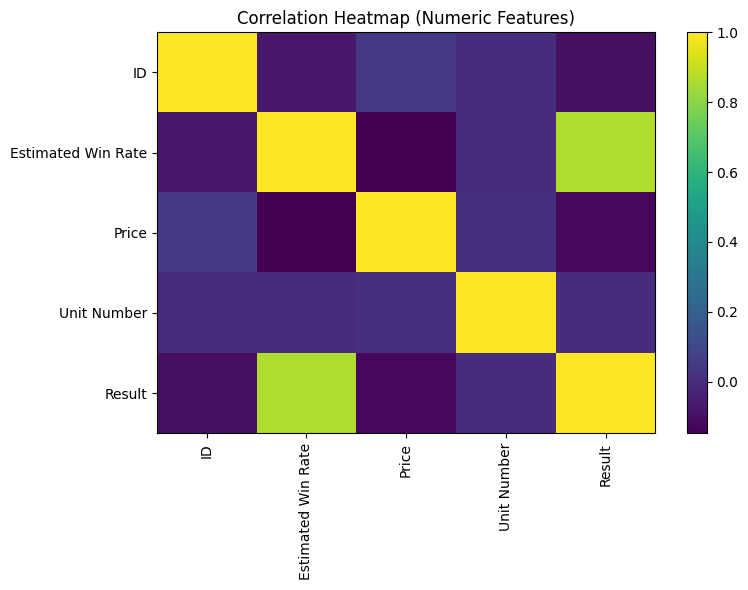

In [112]:
num_cols = DF.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) >= 2:
    corr = DF[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect='auto', interpolation='nearest')
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.xticks(range(len(num_cols)), num_cols, rotation=90)
    plt.yticks(range(len(num_cols)), num_cols)
    plt.colorbar()
    plt.tight_layout()
    maybe_save("correlation_heatmap")
    plt.show()


### BoxPlots vs Target

/var/folders/0j/n9gvt8712g905vzp6jvsf4nc0000gp/T/ipykernel_14460/1362779483.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=labels, showfliers=False)
/var/folders/0j/n9gvt8712g905vzp6jvsf4nc0000gp/T/ipykernel_14460/1362779483.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=labels, showfliers=False)
/var/folders/0j/n9gvt8712g905vzp6jvsf4nc0000gp/T/ipykernel_14460/1362779483.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=labels, showfliers=False)
/var/folders/0j/n9gvt8712g905vzp6jvsf4nc0000gp/T/ipykernel_14

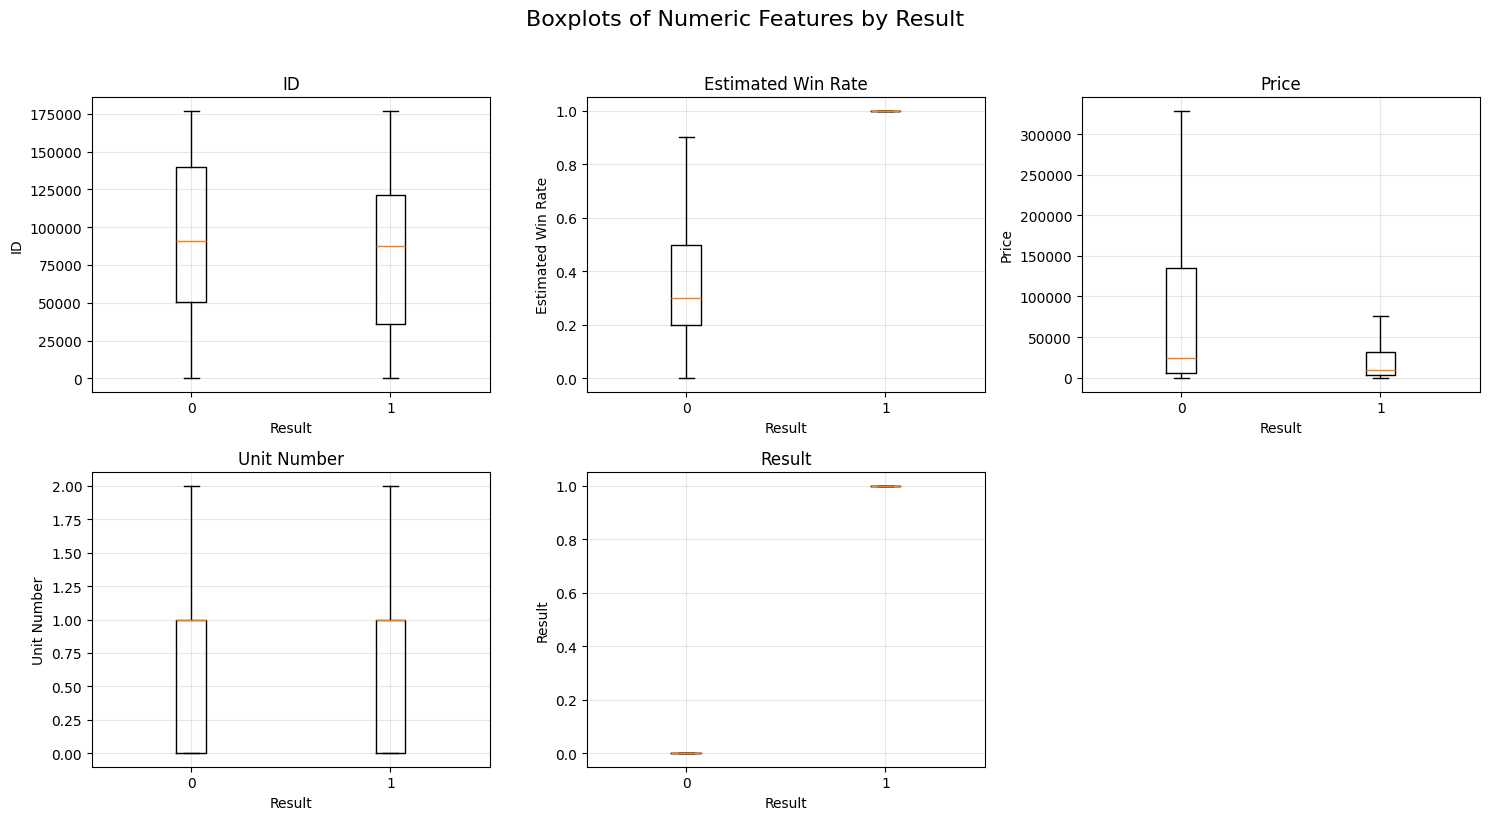

Created boxplots for 5 numeric features by Result


In [141]:
# BoxPlots vs Target - Multiple axes in one figure
unique_targets = DF[TARGET].dropna().unique()
# Only do if target is categorical-like (few classes)
if len(unique_targets) <= 10 and len(num_cols) > 0:
    # Order classes for consistent plotting
    try:
        # Try numeric sort
        class_order = sorted(unique_targets)
    except Exception:
        # Fallback to string sort
        class_order = sorted([str(x) for x in unique_targets])

    # Filter numeric columns that have valid data for boxplots
    valid_cols = []
    for c in num_cols[:MAX_BOX_PLOTS]:
        data_by_class = []
        for cls in class_order:
            if cls in DF[TARGET].values:
                arr = pd.to_numeric(DF.loc[DF[TARGET] == cls, c], errors="coerce").dropna().values
                if len(arr) > 0:
                    data_by_class.append(arr)
        if len(data_by_class) >= 2:  # Need at least 2 classes with data
            valid_cols.append(c)
    
    if valid_cols:
        # Calculate subplot grid dimensions
        n_cols = min(3, len(valid_cols))  # Max 3 columns
        n_rows = (len(valid_cols) + n_cols - 1) // n_cols  # Ceiling division
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
        fig.suptitle(f'Boxplots of Numeric Features by {TARGET}', fontsize=16, y=1.02)
        
        # Handle case where we have only one subplot
        if n_rows == 1 and n_cols == 1:
            axes = [axes]
        elif n_rows == 1 or n_cols == 1:
            axes = axes.flatten()
        else:
            axes = axes.flatten()
        
        for i, c in enumerate(valid_cols):
            ax = axes[i] if len(valid_cols) > 1 else axes[0]
            
            # Prepare data for this feature
            data_by_class = []
            labels = []
            for cls in class_order:
                if cls in DF[TARGET].values:
                    arr = pd.to_numeric(DF.loc[DF[TARGET] == cls, c], errors="coerce").dropna().values
                    if len(arr) > 0:
                        data_by_class.append(arr)
                        labels.append(str(cls))
            
            if len(data_by_class) >= 2:
                ax.boxplot(data_by_class, labels=labels, showfliers=False)
                ax.set_title(f'{c}', fontsize=12)
                ax.set_xlabel(TARGET)
                ax.set_ylabel(c)
                ax.grid(True, alpha=0.3)
        
        # Hide empty subplots
        for i in range(len(valid_cols), len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        maybe_save(f"boxplots_all_by_{TARGET}")
        plt.show()
        
        print(f"Created boxplots for {len(valid_cols)} numeric features by {TARGET}")
    else:
        print(f"No valid numeric columns found for boxplot analysis by {TARGET}")
else:
    print(f"Target has {len(unique_targets)} unique values - too many for boxplot analysis (max 10)")

In [117]:
train_df_clean.head()
test_df_clean.head()

,ID,Start Date,End Date,Estimated Win Rate,Price,Customer Segment 1,Customer Segment 2,Customer Segment 3,Customer Segment 4,Customer Segment 5,...,Country,City,Product,Competitor,Marketing Source,Division,Manager,Techincal Manager,Customer ID,Result
0,177087,2018-02-11,2018-09-04,1.00,3000.000000,I,A,AA,CCC,AB,...,GHI,LNO392,VUI150,missing,JWP393,EM41,NaN,NaN,0017Q00001G4YkIQAV,NaN
1,177088,2018-11-14,2019-03-05,0.75,250000.000000,I,A,AA,CCC,AB,...,GHI,LNO392,IEJ418,missing,JWP393,QO91,NaN,NaN,0017Q00001G4YheQAF,NaN
2,177089,2024-05-16,2024-08-26,0.00,139677.231907,I,D,AA,CCC,AB,...,PQR,FUH372,AHU981,UTG383,missing,UW72,NaN,NaN,0017Q00001G4UAOQA3,NaN
3,177090,2023-02-09,2023-08-21,0.00,5194.576510,I,D,AA,CCC,AB,...,MNO,DIF777,ASH122,SVE211,KAD664,EM41,NaN,NaN,0017Q00001OcHuHQAV,NaN
4,177091,2025-02-11,2025-12-31,0.00,132065.504490,I,A,AA,CCC,AB,...,PQR,FUH372,AHU981,UTG383,RMD495,UW72,NaN,NaN,0017Q00001G4ZolQAF,NaN


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print(f"Training data shape: {train_df_clean.shape}")
print(f"Test data shape: {test_df_clean.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

# Correct test IDs to continue from training data
test_df_clean['ID'] = range(177087, 177087 + len(test_df_clean))
print(f"Test IDs corrected: {test_df_clean['ID'].min()} to {test_df_clean['ID'].max()}")

# Extract and validate target variable
y = train_df_clean['Result'].values.astype(int)
print(f"\nTarget distribution: Class 0={sum(y==0)}, Class 1={sum(y==1)}")
print(f"Class balance: {sum(y==1)/len(y)*100:.1f}% positive class")


Step 1: Loading datasets...
Training data shape: (177086, 23)
Test data shape: (44272, 23)
Sample submission shape: (4, 2)
Test IDs corrected: 177087 to 221358

Target distribution: Class 0=101421, Class 1=75665
Class balance: 42.7% positive class


In [119]:
# Feature engineering function with proper type hints
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Engineer features from the raw dataframe.
    
    Args:
        df: Input dataframe with raw features
        
    Returns:
        DataFrame with engineered features
    """
    df = df.copy()
    
    # Date features
    for col in ['Start Date', 'End Date']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Handle Contract End Date specifically  
    if 'Contract End Date' in df.columns:
        df['End Date'] = pd.to_datetime(df['Contract End Date'], errors='coerce')
    
    # Date feature engineering
    if 'Start Date' in df.columns and 'End Date' in df.columns:
        df['Journey_Duration'] = (df['End Date'] - df['Start Date']).dt.days
        # Clip to reasonable range (0-365 days), fill NaNs with 0
        df['Journey_Duration'] = df['Journey_Duration'].fillna(0).clip(lower=0, upper=365)

        # Remove unrealistic start dates
        df.loc[df['Start Date'].dt.year < 1950, 'Start Date'] = pd.NaT
        df['Start_Year'] = df['Start Date'].dt.year.fillna(df['Start Date'].dt.year.median())

        df['Start_Month'] = df['Start Date'].dt.month.fillna(6)
        df['Start_Quarter'] = df['Start Date'].dt.quarter.fillna(2)
        df['Start_DayOfWeek'] = df['Start Date'].dt.dayofweek.fillna(3)

        df['End_Year'] = df['End Date'].dt.year.fillna(df['End Date'].dt.year.median())
        df['End_Month'] = df['End Date'].dt.month.fillna(6)
        df['End_Quarter'] = df['End Date'].dt.quarter.fillna(2)
        df['End_DayOfWeek'] = df['End Date'].dt.dayofweek.fillna(3)

        # Drop original date columns
        df = df.drop(['Start Date', 'End Date'], axis=1)
        if 'Contract End Date' in df.columns:
            df = df.drop(['Contract End Date'], axis=1)

    # Numerical features
    if 'Price' in df.columns:
        price_median = df['Price'].median()
        df['Price'] = df['Price'].fillna(price_median)
        # Normalizing price to its log equivalent
        df['Price_Log'] = np.log1p(df['Price'].clip(lower=0))
        # Square root transformation for price
        df['Price_Sqrt'] = np.sqrt(df['Price'].clip(lower=0))
    
    if 'Estimated Win Rate' in df.columns:
        df['Estimated Win Rate'] = df['Estimated Win Rate'].fillna(df['Estimated Win Rate'].median())
        df['Win_Rate_Squared'] = df['Estimated Win Rate'] ** 2
        df['Win_Rate_High'] = (df['Estimated Win Rate'] > 0.75).astype(int)
        df['Win_Rate_Low'] = (df['Estimated Win Rate'] < 0.25).astype(int)
    
    if 'Unit Number' in df.columns:
        df['Unit Number'] = df['Unit Number'].fillna(0)
        df['Unit_Log'] = np.log1p(df['Unit Number'])
        df['Has_Units'] = (df['Unit Number'] > 0).astype(int)
        df['Multiple_Units'] = (df['Unit Number'] > 1).astype(int)
    
    # Customer segments
    segment_cols = [f'Customer Segment {i}' for i in range(1, 6)]
    existing_segments = [col for col in segment_cols if col in df.columns]
    if existing_segments:
        df['Active_Segments'] = df[existing_segments].notna().sum(axis=1)
    
    # Manager features
    if 'Manager' in df.columns:
        df['Has_Manager'] = df['Manager'].notna().astype(int)
    if 'Techincal Manager' in df.columns:
        df['Has_Tech_Manager'] = df['Techincal Manager'].notna().astype(int)
    
    return df

In [120]:
print("\nStep 2: Engineering features...")
train_featured = engineer_features(train_df_clean)
test_featured = engineer_features(test_df_clean)

train_featured.columns


Step 2: Engineering features...


Index(['ID', 'Estimated Win Rate', 'Price', 'Customer Segment 1',
       'Customer Segment 2', 'Customer Segment 3', 'Customer Segment 4',
       'Customer Segment 5', 'Unit Number', 'Activity 1', 'Activity 2',
       'Country', 'City', 'Product', 'Competitor', 'Marketing Source',
       'Division', 'Manager', 'Techincal Manager', 'Customer ID', 'Result',
       'Journey_Duration', 'Start_Year', 'Start_Month', 'Start_Quarter',
       'Start_DayOfWeek', 'End_Year', 'End_Month', 'End_Quarter',
       'End_DayOfWeek', 'Price_Log', 'Price_Sqrt', 'Win_Rate_Squared',
       'Win_Rate_High', 'Win_Rate_Low', 'Unit_Log', 'Has_Units',
       'Multiple_Units', 'Active_Segments', 'Has_Manager', 'Has_Tech_Manager'],
      dtype='object')

### Visualizations of Engineered Features and Model Predictions

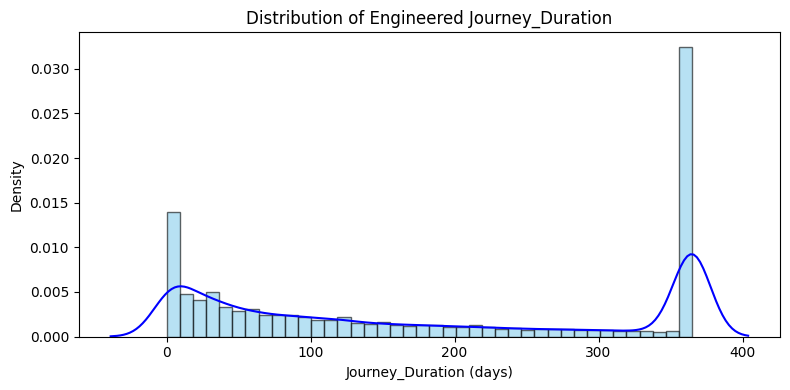

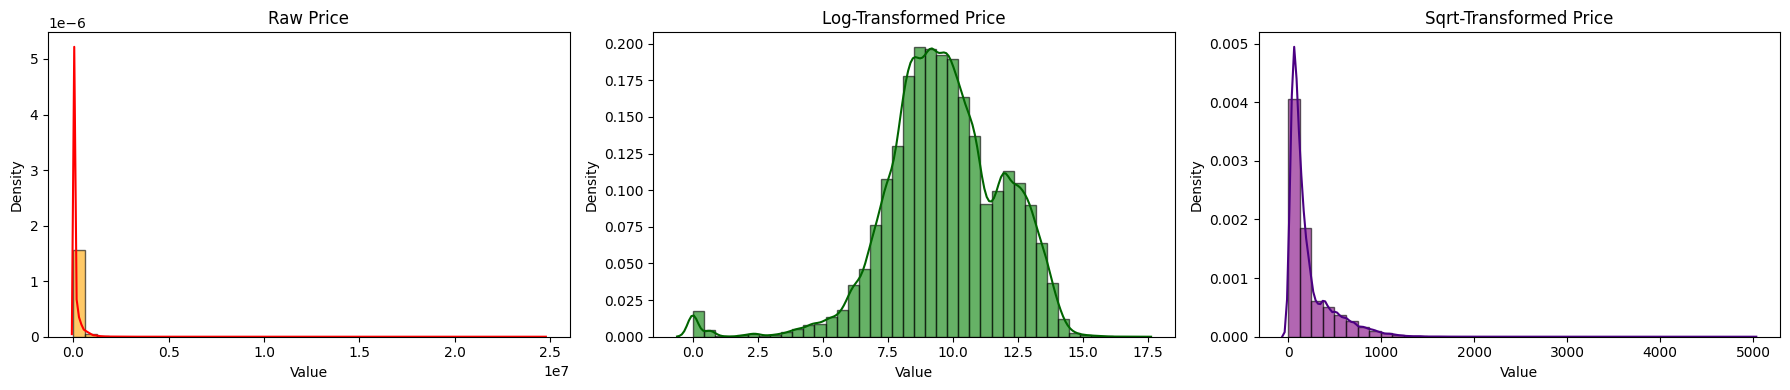

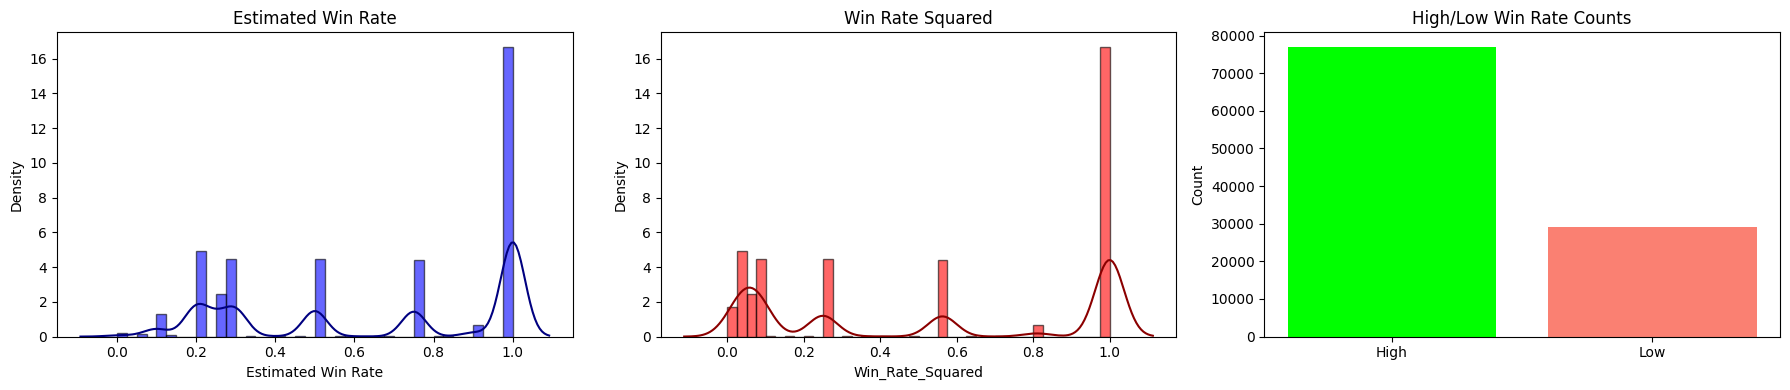

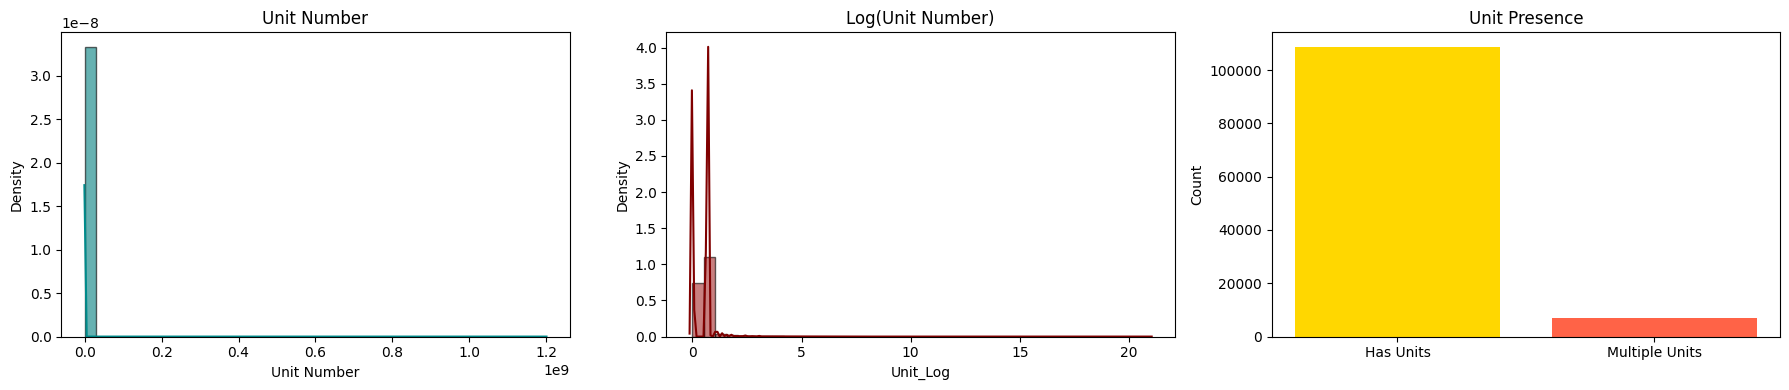

/var/folders/0j/n9gvt8712g905vzp6jvsf4nc0000gp/T/ipykernel_14460/3073927084.py:70: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(train_featured['Active_Segments'], color='orange')


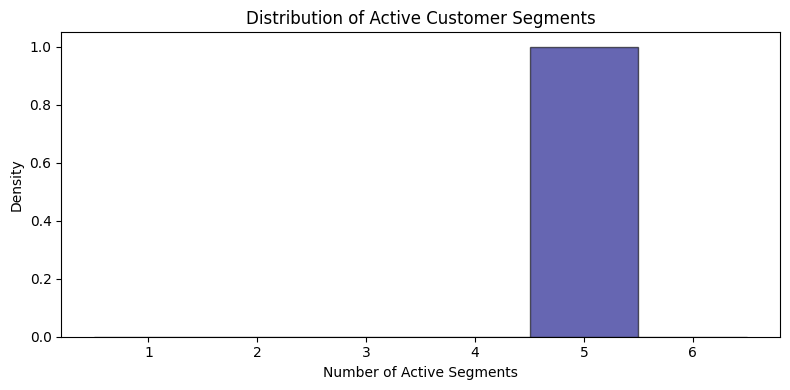

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Journey_Duration distribution (after feature engineering)
if 'Journey_Duration' in train_featured.columns:
    plt.figure(figsize=(8,4))
    plt.hist(train_featured['Journey_Duration'], bins=40, color='skyblue', edgecolor='black', density=True, alpha=0.6)
    sns.kdeplot(train_featured['Journey_Duration'], color='blue')
    plt.title('Distribution of Engineered Journey_Duration')
    plt.xlabel('Journey_Duration (days)')
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

# 2. Price transformations: raw, log, sqrt
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(train_featured['Price'], bins=40, color='orange', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Price'], color='red', ax=axes[0])
axes[0].set_title('Raw Price')
axes[1].hist(train_featured['Price_Log'], bins=40, color='green', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Price_Log'], color='darkgreen', ax=axes[1])
axes[1].set_title('Log-Transformed Price')
axes[2].hist(train_featured['Price_Sqrt'], bins=40, color='purple', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Price_Sqrt'], color='indigo', ax=axes[2])
axes[2].set_title('Sqrt-Transformed Price')
for ax in axes:
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

# 3. Estimated Win Rate features
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(train_featured['Estimated Win Rate'], bins=40, color='blue', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Estimated Win Rate'], color='navy', ax=axes[0])
axes[0].set_title('Estimated Win Rate')
axes[1].hist(train_featured['Win_Rate_Squared'], bins=40, color='red', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Win_Rate_Squared'], color='darkred', ax=axes[1])
axes[1].set_title('Win Rate Squared')
axes[2].bar(['High', 'Low'], [
    train_featured['Win_Rate_High'].sum(),
    train_featured['Win_Rate_Low'].sum()
], color=['lime', 'salmon'])
axes[2].set_title('High/Low Win Rate Counts')
axes[2].set_ylabel('Count')
plt.tight_layout()
plt.show()

# 4. Unit Number features
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(train_featured['Unit Number'], bins=40, color='teal', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Unit Number'], color='darkcyan', ax=axes[0])
axes[0].set_title('Unit Number')
axes[1].hist(train_featured['Unit_Log'], bins=40, color='brown', edgecolor='black', density=True, alpha=0.6)
sns.kdeplot(train_featured['Unit_Log'], color='maroon', ax=axes[1])
axes[1].set_title('Log(Unit Number)')
axes[2].bar(['Has Units', 'Multiple Units'], [
    train_featured['Has_Units'].sum(),
    train_featured['Multiple_Units'].sum()
], color=['gold', 'tomato'])
axes[2].set_title('Unit Presence')
axes[2].set_ylabel('Count')
plt.tight_layout()
plt.show()

# 5. Active Customer Segments
if 'Active_Segments' in train_featured.columns:
    plt.figure(figsize=(8,4))
    plt.hist(train_featured['Active_Segments'], bins=range(1, 8), color='navy', edgecolor='black', align='left', density=True, alpha=0.6)
    sns.kdeplot(train_featured['Active_Segments'], color='orange')
    plt.title('Distribution of Active Customer Segments')
    plt.xlabel('Number of Active Segments')
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()


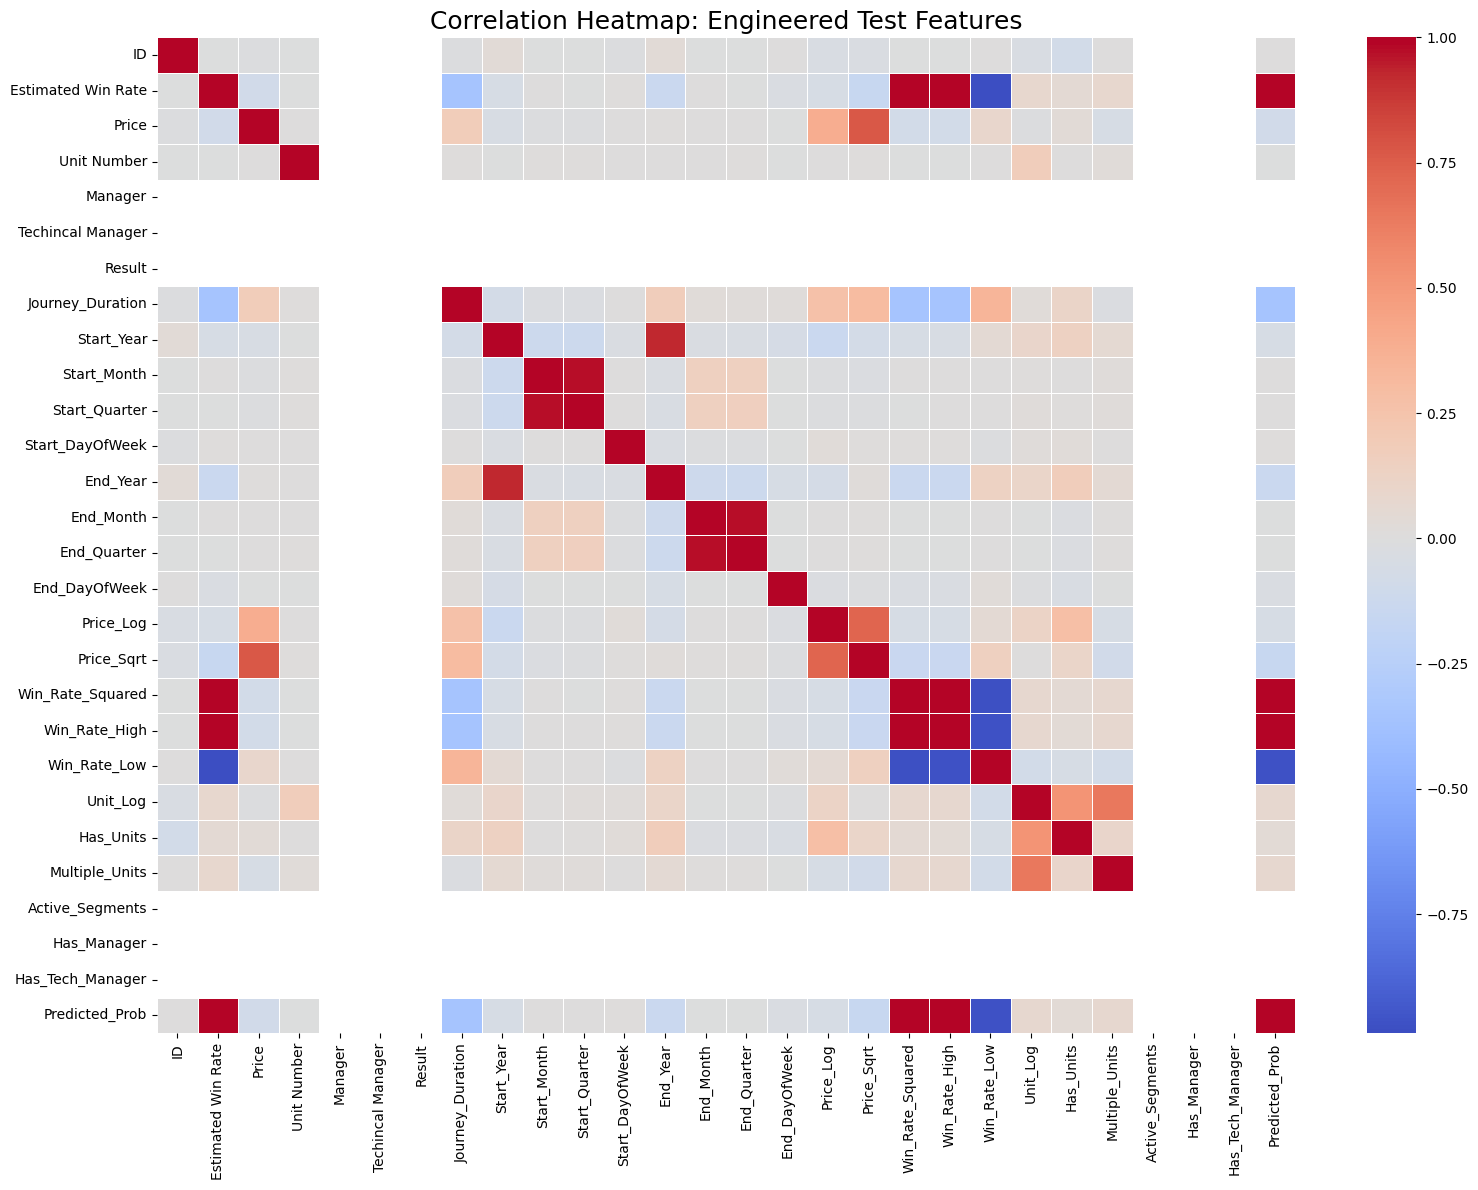

In [140]:

#### Correlation Heatmap of Engineered Test Features

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_cols = test_featured.select_dtypes(include=['number']).columns
corr_matrix = test_featured[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap: Engineered Test Features', fontsize=18)
plt.tight_layout()
plt.show()


Features selected: 38 common features

Step 3: Encoding categorical variables...
Categorical columns to encode: 15
Final shapes - Training: (177086, 38), Test: (44272, 38)

Step 4: Training models...
Final shapes - Training: (177086, 38), Test: (44272, 38)

Step 4: Training models...

Training RandomForest...

Training RandomForest...
  Validation AUC: 0.9977
  Validation Accuracy: 0.9907

Training XGBoost...
  Validation AUC: 0.9977
  Validation Accuracy: 0.9907

Training XGBoost...


/Users/etloaner/Documents/Projects/Purchase-Intent-Prediction/purvenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:24:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Validation AUC: 0.9979
  Validation Accuracy: 0.9914

Training LightGBM...


/Users/etloaner/Documents/Projects/Purchase-Intent-Prediction/purvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/etloaner/Documents/Projects/Purchase-Intent-Prediction/purvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/etloaner/Documents/Projects/Purchase-Intent-Prediction/purvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/etloaner/Documents/Projects/Purchase-Intent-Prediction/purvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Use

  Validation AUC: 0.9978
  Validation Accuracy: 0.9913

Training GradientBoosting...
  Validation AUC: 0.9978
  Validation Accuracy: 0.9906

Step 5: Creating ensemble predictions...
Model weights based on AUC:
  XGBoost: 0.250
  LightGBM: 0.250
  GradientBoosting: 0.250
  RandomForest: 0.250

Step 6: Retraining on full dataset...
Retraining RandomForest...
  Validation AUC: 0.9978
  Validation Accuracy: 0.9906

Step 5: Creating ensemble predictions...
Model weights based on AUC:
  XGBoost: 0.250
  LightGBM: 0.250
  GradientBoosting: 0.250
  RandomForest: 0.250

Step 6: Retraining on full dataset...
Retraining RandomForest...
Retraining XGBoost...
Retraining XGBoost...


/Users/etloaner/Documents/Projects/Purchase-Intent-Prediction/purvenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:25:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Retraining LightGBM...


/Users/etloaner/Documents/Projects/Purchase-Intent-Prediction/purvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/etloaner/Documents/Projects/Purchase-Intent-Prediction/purvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/etloaner/Documents/Projects/Purchase-Intent-Prediction/purvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Retraining GradientBoosting...

Step 7: Creating submission files...

SUBMISSION FILE 1: PROBABILITY PREDICTIONS
File name: submission_probability.csv
Shape: (44272, 2)
TARGET range: [0.0001, 0.9974]
TARGET mean: 0.3057
TARGET std: 0.4542

First 5 rows:
       ID    TARGET
0  177087  0.987652
1  177088  0.007881
2  177089  0.000626
3  177090  0.004583
4  177091  0.000194

SUBMISSION FILE 2: BINARY PREDICTIONS
File name: submission_binary.csv
Shape: (44272, 2)
Class distribution: 0=30578, 1=13694
Positive class percentage: 30.9%

First 5 rows:
       ID  TARGET
0  177087       1
1  177088       0
2  177089       0
3  177090       0
4  177091       0

Step 7: Creating submission files...

SUBMISSION FILE 1: PROBABILITY PREDICTIONS
File name: submission_probability.csv
Shape: (44272, 2)
TARGET range: [0.0001, 0.9974]
TARGET mean: 0.3057
TARGET std: 0.4542

First 5 rows:
       ID    TARGET
0  177087  0.987652
1  177088  0.007881
2  177089  0.000626
3  177090  0.004583
4  177091  0.000194


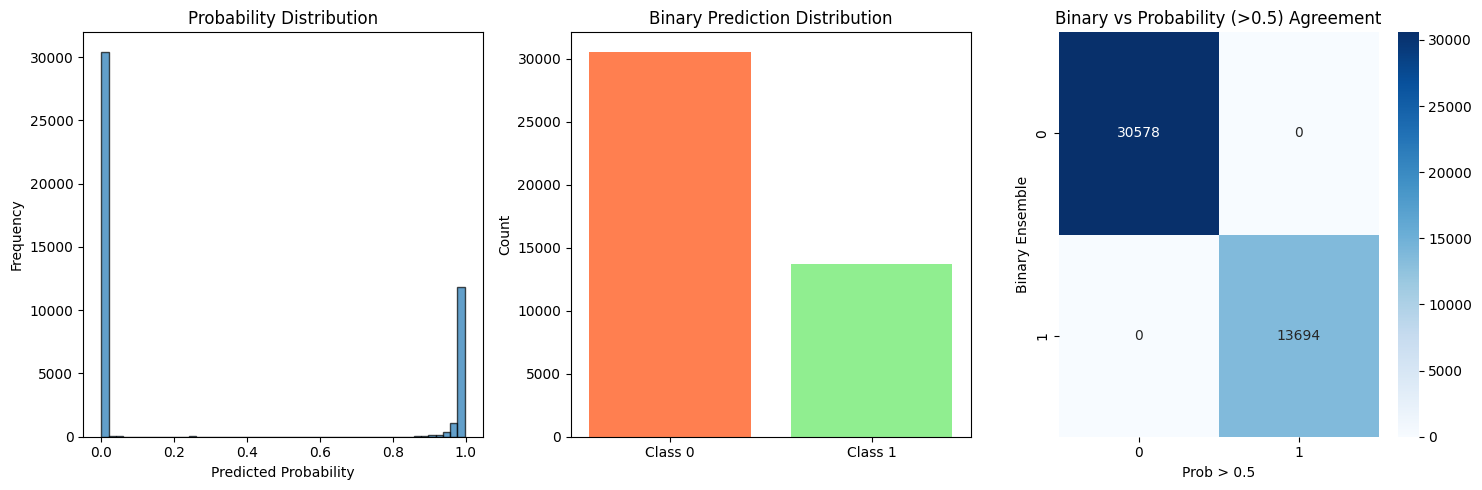


PIPELINE COMPLETED SUCCESSFULLY

Two submission files created:
1. submission_probability.csv - Use this for ROC AUC evaluation
2. submission_binary.csv - Binary classification output

The competition requires probability predictions for ROC AUC scoring.


In [121]:


# Prepare feature matrices
exclude_cols = ['ID', 'Result', 'Customer ID']
feature_cols = [col for col in train_featured.columns if col not in exclude_cols]

X = train_featured[feature_cols].copy()
X_test = test_featured[feature_cols].copy()

# Align columns
common_cols = sorted(list(set(X.columns) & set(X_test.columns)))
X = X[common_cols]
X_test = X_test[common_cols]

print(f"Features selected: {len(common_cols)} common features")

# Encode categorical features
print("\nStep 3: Encoding categorical variables...")
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Categorical columns to encode: {len(categorical_cols)}")

for col in categorical_cols:
    le = LabelEncoder()
    
    X[col] = X[col].fillna('missing').astype(str)
    X_test[col] = X_test[col].fillna('missing').astype(str)
    
    all_values = pd.concat([X[col], X_test[col]]).unique()
    le.fit(all_values)
    
    X[col] = le.transform(X[col])
    X_test[col] = le.transform(X_test[col])

# Handle remaining missing values
for col in X.columns:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

# Convert to arrays
X = X.values.astype(np.float32)
X_test = X_test.values.astype(np.float32)

print(f"Final shapes - Training: {X.shape}, Test: {X_test.shape}")

# Model training
print("\nStep 4: Training models...")
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=150, max_depth=12, min_samples_split=15,
        min_samples_leaf=8, max_features='sqrt',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, use_label_encoder=False, eval_metric='logloss'
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.08,
        num_leaves=40, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=150, max_depth=5, learning_rate=0.08,
        subsample=0.8, max_features='sqrt',
        random_state=42
    )
}

validation_scores = {}
test_probabilities = {}
test_binary = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Validation performance
    val_prob = model.predict_proba(X_val)[:, 1]
    val_binary = model.predict(X_val)
    
    auc = roc_auc_score(y_val, val_prob)
    acc = accuracy_score(y_val, val_binary)
    validation_scores[name] = auc
    
    # Test predictions - both probability and binary
    test_prob = model.predict_proba(X_test)[:, 1]
    test_bin = model.predict(X_test)
    
    test_probabilities[name] = test_prob
    test_binary[name] = test_bin
    
    print(f"  Validation AUC: {auc:.4f}")
    print(f"  Validation Accuracy: {acc:.4f}")

# Create ensembles
print("\nStep 5: Creating ensemble predictions...")

# Calculate weights based on AUC scores
total_score = sum(validation_scores.values())
weights = {name: score/total_score for name, score in validation_scores.items()}

print("Model weights based on AUC:")
for name, weight in sorted(weights.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {weight:.3f}")

# Weighted ensemble for probabilities
ensemble_prob = np.zeros(len(X_test))
for name, weight in weights.items():
    ensemble_prob += test_probabilities[name] * weight

# Majority voting for binary predictions
ensemble_binary_votes = np.array(list(test_binary.values()))
ensemble_binary = (ensemble_binary_votes.sum(axis=0) >= len(models)/2).astype(int)

# Retrain on full data for final predictions
print("\nStep 6: Retraining on full dataset...")
final_probabilities = []
final_binary_predictions = []

for name, model in models.items():
    print(f"Retraining {name}...")
    model.fit(X, y)
    
    prob = model.predict_proba(X_test)[:, 1]
    binary = model.predict(X_test)
    
    final_probabilities.append(prob)
    final_binary_predictions.append(binary)

# Final ensembles
final_ensemble_prob = np.mean(final_probabilities, axis=0)
final_ensemble_binary = (np.array(final_binary_predictions).sum(axis=0) >= len(models)/2).astype(int)

# Create submission files
print("\nStep 7: Creating submission files...")

# Submission 1: Probability predictions (for ROC AUC evaluation)
submission_probability = pd.DataFrame({
    'ID': test_featured['ID'].values,
    'TARGET': final_ensemble_prob
})
submission_probability['TARGET'] = submission_probability['TARGET'].clip(0.0001, 0.9999)

# Submission 2: Binary predictions
submission_binary = pd.DataFrame({
    'ID': test_featured['ID'].values,
    'TARGET': final_ensemble_binary
})

# Save both files
submission_probability.to_csv('submission_probability.csv', index=False)
submission_binary.to_csv('submission_binary.csv', index=False)

# Display statistics
print("\n" + "=" * 60)
print("SUBMISSION FILE 1: PROBABILITY PREDICTIONS")
print("File name: submission_probability.csv")
print(f"Shape: {submission_probability.shape}")
print(f"TARGET range: [{submission_probability['TARGET'].min():.4f}, {submission_probability['TARGET'].max():.4f}]")
print(f"TARGET mean: {submission_probability['TARGET'].mean():.4f}")
print(f"TARGET std: {submission_probability['TARGET'].std():.4f}")
print("\nFirst 5 rows:")
print(submission_probability.head())

print("\n" + "=" * 60)
print("SUBMISSION FILE 2: BINARY PREDICTIONS")
print("File name: submission_binary.csv")
print(f"Shape: {submission_binary.shape}")
print(f"Class distribution: 0={sum(submission_binary['TARGET']==0)}, 1={sum(submission_binary['TARGET']==1)}")
print(f"Positive class percentage: {sum(submission_binary['TARGET']==1)/len(submission_binary)*100:.1f}%")
print("\nFirst 5 rows:")
print(submission_binary.head())

# Comparison visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(submission_probability['TARGET'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.bar(['Class 0', 'Class 1'], 
        [sum(submission_binary['TARGET']==0), sum(submission_binary['TARGET']==1)],
        color=['coral', 'lightgreen'])
plt.title('Binary Prediction Distribution')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
threshold = 0.5
binary_from_prob = (submission_probability['TARGET'] > threshold).astype(int)
confusion = pd.crosstab(submission_binary['TARGET'], binary_from_prob, 
                        rownames=['Binary Ensemble'], colnames=['Prob > 0.5'])
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.title('Binary vs Probability (>0.5) Agreement')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("\nTwo submission files created:")
print("1. submission_probability.csv - Use this for ROC AUC evaluation")
print("2. submission_binary.csv - Binary classification output")
print("\nThe competition requires probability predictions for ROC AUC scoring.")
print("=" * 60)